In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import re
from collections import Counter

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
CON = Path("/kaggle/input/datasets/zennightshade/mental/preprocessed/mentalmanip_con.csv")
MAJ = Path("/kaggle/input/datasets/zennightshade/mental/preprocessed/mentalmanip_maj.csv")

In [3]:
class Vocab:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {"<pad>": 0, "<unk>": 1}
        self.idx2word = {0: "<pad>", 1: "<unk>"}

    def tokenize(self, text):
        text = text.lower()
        text = re.sub(r"[^a-z0-9\s]", "", text)
        return text.split()

    def build(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self.tokenize(text))

        for word, freq in counter.items():
            if freq >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, text):
        return [self.word2idx.get(t, 1) for t in self.tokenize(text)]

In [4]:
class MentalManipDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def pad(self, seq):
        if len(seq) < self.max_len:
            return seq + [0] * (self.max_len - len(seq))
        return seq[:self.max_len]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.vocab.encode(self.texts[idx])
        padded = self.pad(encoded)

        return torch.tensor(padded), torch.tensor(self.labels[idx])

In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=12):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (hidden, _) = self.lstm(emb)
        out = hidden[-1]
        return self.fc(out)

In [6]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=12):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (hidden, _) = self.lstm(emb)

        hidden_f = hidden[-2]
        hidden_b = hidden[-1]

        out = torch.cat((hidden_f, hidden_b), dim=1)
        return self.fc(out)

In [7]:
def get_class_weights(labels):
    classes = np.unique(labels)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=labels
    )

    # Map to full tensor (size = num_classes)
    num_classes = max(labels) + 1
    weight_tensor = torch.ones(num_classes)

    for cls, w in zip(classes, weights):
        weight_tensor[cls] = w

    return weight_tensor

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate(model, loader, device, name="Eval", num_classes=12):
    model.eval()

    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu()

            preds.extend(pred.numpy())
            labels.extend(y.numpy())

    # Metrics
    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)

    cm = confusion_matrix(labels, preds)

    print(f"\n{name} Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(labels, preds, zero_division=0))

    plt.figure()
    
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.colorbar()
    
    ticks = np.arange(num_classes)
    plt.xticks(ticks)
    plt.yticks(ticks)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center")
    
    plt.tight_layout()
    plt.savefig(f"{name.lower()}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    
    plt.show()

In [9]:
def train(model, train_loader, val_loader, class_weights, epochs=5, lr=1e-3, device="cuda"):
    model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"\nEpoch {epoch+1}", end= ":\t")
        print(f"Train Loss: {total_loss:.4f}", end= "")

    evaluate(model, train_loader, device, name="Train")
    evaluate(model, val_loader, device, name="Validation")

In [13]:
# ===== LOAD YOUR DATA HERE =====
df = pd.read_csv(MAJ)
texts = df["Dialogue"].tolist()
labels = df["label"].tolist()

# Split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

# Build vocab ONLY on train
vocab = Vocab(min_freq=2)
vocab.build(train_texts)

# Datasets
train_dataset = MentalManipDataset(train_texts, train_labels, vocab)
val_dataset = MentalManipDataset(val_texts, val_labels, vocab)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Class weights
class_weights = get_class_weights(train_labels)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"


Epoch 1:	Train Loss: 207.1277
Epoch 2:	Train Loss: 195.8422
Epoch 3:	Train Loss: 191.4242
Epoch 4:	Train Loss: 189.8299
Epoch 5:	Train Loss: 187.4023
Epoch 6:	Train Loss: 184.8717
Epoch 7:	Train Loss: 181.9011
Epoch 8:	Train Loss: 179.0242
Epoch 9:	Train Loss: 176.6352
Epoch 10:	Train Loss: 170.6047
Epoch 11:	Train Loss: 168.2251
Epoch 12:	Train Loss: 164.2331
Epoch 13:	Train Loss: 160.4770
Epoch 14:	Train Loss: 156.4518
Epoch 15:	Train Loss: 154.0645
Epoch 16:	Train Loss: 148.2588
Epoch 17:	Train Loss: 145.7478
Epoch 18:	Train Loss: 142.4981
Epoch 19:	Train Loss: 138.0894
Epoch 20:	Train Loss: 137.1132
Epoch 21:	Train Loss: 136.7060
Epoch 22:	Train Loss: 136.6811
Epoch 23:	Train Loss: 130.1561
Epoch 24:	Train Loss: 128.1906
Epoch 25:	Train Loss: 131.2515
Epoch 26:	Train Loss: 124.6460
Epoch 27:	Train Loss: 123.9379
Epoch 28:	Train Loss: 122.1889
Epoch 29:	Train Loss: 120.6377
Epoch 30:	Train Loss: 114.6772
Epoch 31:	Train Loss: 110.2284
Epoch 32:	Train Loss: 106.4595
Epoch 33:	Train 

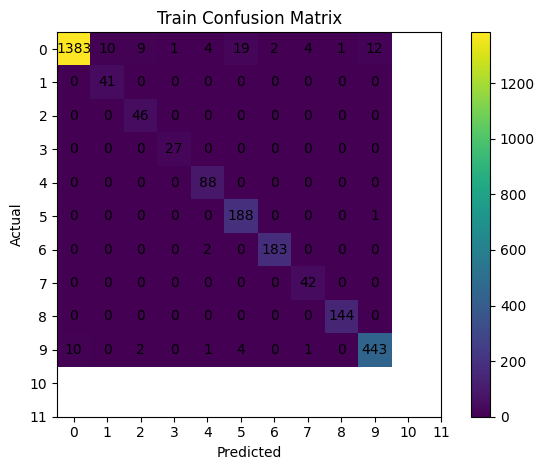


Validation Metrics:
Accuracy : 0.3189
Precision: 0.0981
Recall   : 0.0987
F1 Score : 0.0983

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.49      0.50       362
           1       0.09      0.09      0.09        11
           2       0.00      0.00      0.00        12
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00        22
           7       0.02      0.02      0.02        47
           8       0.07      0.07      0.07        46
           9       0.00      0.00      0.00        10
          10       0.08      0.08      0.08        36
          11       0.21      0.23      0.22       115

    accuracy                           0.32       668
   macro avg       0.10      0.10      0.10       668
weighted avg       0.33      0.32      0.32       668



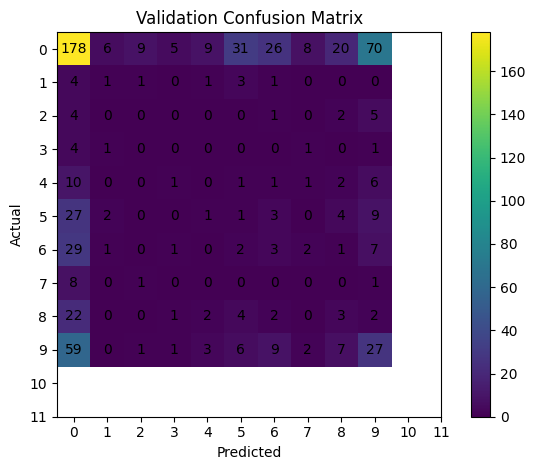

In [14]:
model = LSTMClassifier(len(vocab.word2idx))
train(model, train_loader, val_loader, class_weights, epochs=120, device=device, lr= 3e-4)


Epoch 1:	Train Loss: 202.9769
Epoch 2:	Train Loss: 193.4749
Epoch 3:	Train Loss: 188.8441
Epoch 4:	Train Loss: 183.6623
Epoch 5:	Train Loss: 174.5653
Epoch 6:	Train Loss: 162.8101
Epoch 7:	Train Loss: 144.3129
Epoch 8:	Train Loss: 126.4530
Epoch 9:	Train Loss: 108.8047
Epoch 10:	Train Loss: 92.1336
Epoch 11:	Train Loss: 79.9944
Epoch 12:	Train Loss: 69.7213
Epoch 13:	Train Loss: 58.6589
Epoch 14:	Train Loss: 49.8644
Epoch 15:	Train Loss: 43.9388
Epoch 16:	Train Loss: 36.1813
Epoch 17:	Train Loss: 31.9894
Epoch 18:	Train Loss: 30.9190
Epoch 19:	Train Loss: 24.2743
Epoch 20:	Train Loss: 20.8047
Epoch 21:	Train Loss: 17.2975
Epoch 22:	Train Loss: 15.0888
Epoch 23:	Train Loss: 13.4450
Epoch 24:	Train Loss: 11.3874
Epoch 25:	Train Loss: 10.8288
Epoch 26:	Train Loss: 9.3422
Epoch 27:	Train Loss: 9.5091
Epoch 28:	Train Loss: 7.1681
Epoch 29:	Train Loss: 5.6782
Epoch 30:	Train Loss: 4.6374
Epoch 31:	Train Loss: 3.9623
Epoch 32:	Train Loss: 3.5277
Epoch 33:	Train Loss: 2.9161
Epoch 34:	Train L

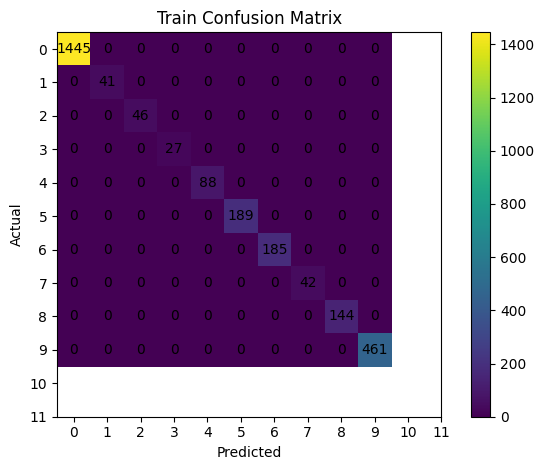


Validation Metrics:
Accuracy : 0.3862
Precision: 0.1157
Recall   : 0.1134
F1 Score : 0.1135

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.64      0.59       362
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        12
           3       0.17      0.14      0.15         7
           4       0.00      0.00      0.00        22
           7       0.13      0.11      0.12        47
           8       0.05      0.04      0.05        46
           9       0.00      0.00      0.00        10
          10       0.08      0.06      0.06        36
          11       0.19      0.15      0.17       115

    accuracy                           0.39       668
   macro avg       0.12      0.11      0.11       668
weighted avg       0.34      0.39      0.36       668



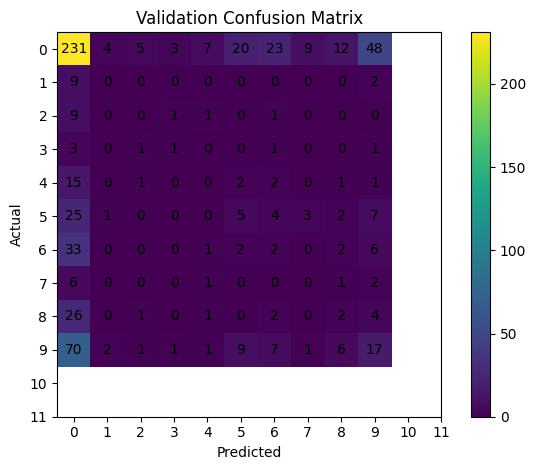

In [15]:
model = BiLSTMClassifier(len(vocab.word2idx))
train(model, train_loader, val_loader, class_weights, epochs=120, device=device, lr= 3e-4)